# CRLA School Performance — Prediction Models
### Predicting `overall_mps` from Total Teachers, Total Enrollees, Mother Tongue MPS, Region, and Total Facilities

This notebook builds two prediction models on the CRLA dataset:

1. **Linear Regression** — predicts the continuous outcome `overall_mps` (the school's overall mean percentage score).
2. **Logistic Regression** — predicts a binary outcome, whether a school is **High Performing** (`overall_mps` at/above the median) or not, using the same predictors.

**Predictors used (as requested):**
- `total_teachers`
- `total_enrollees`
- `mother_tongue_mps`
- `region`
- `total_facilities`

**Important note on predictors:** the dataset also contains `english_mps`, `filipino_mps`, `numeracy_mps`, `mps`, and `overall_mps`. These are **excluded from the predictor set** (except `mother_tongue_mps`, which was explicitly requested) because they are components/aggregates used to *compute* the target itself — including them would leak the answer into the model and artificially inflate R² in a meaningless way.

We push R² up (while staying within these 5 requested predictors) by:
- Cleaning missing values,
- One-hot encoding `region`,
- Adding **polynomial/interaction terms** (degree 2) on the numeric predictors, which lets the linear model capture non-linear relationships (e.g. diminishing returns of more teachers) without changing which raw variables are used.


## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)


## 2. Load the Data

In [ ]:
df = pd.read_csv("CRLA_UPDATEDv2.csv")
print("Shape:", df.shape)
df.head()


Shape: (6121, 71)


,school_id,region,division,language,Municipality,District_Name,Barangay,Ownership,Classification,Management,Level,n_test_takers_x,school_low_emerging_total,school_high_emerging_total,school_developing_total,school_transitioning_total,school_at_grade_level_total,school_low_emerging_percent,school_high_emerging_percent,school_developing_percent,school_transitioning_percent,school_at_grade_level_percent,g1_mt_low_emerging,g1_mt_high_emerging,g1_mt_developing,g1_mt_transitioning,g1_mt_at_grade_level,g1_mt_total,g2_mt_low_emerging,g2_mt_high_emerging,...,g3_mt_high_emerging,g3_mt_developing,g3_mt_transitioning,g3_mt_at_grade_level,g3_mt_total,g3_fil_low_emerging,g3_fil_high_emerging,g3_fil_developing,g3_fil_transitioning,g3_fil_at_grade_level,g3_fil_total,g3_eng_low_emerging,g3_eng_high_emerging,g3_eng_developing,g3_eng_transitioning,g3_eng_at_grade_level,g3_eng_total,District,School_Name,Address,total_enrollees,total_facilities,total_teachers,n_test_takers_y,english_mps,filipino_mps,mother_tongue_mps,numeracy_mps,mps,overall_mps
0,135196,CAR,Abra,Ilocano,TINEG,Lone District,ALAOA,Public,Partially Urban,DepED Managed,Purely ES,15,1,6,1,2,5,0.066667,0.40,0.066667,0.133333,0.333333,0,6,0,0,0,6,1,0,...,0,0,1,4,5,0,0,0,1,4,5,0,0,0,1,4,5,Tineg,Alawa Elementary school,Alawa Tineg Abra,33,5.0,6.0,3,38.518519,33.333333,34.814815,25.000000,34.193548,35.555556
1,135050,CAR,Abra,Ilocano,LICUAN-BAAY (LICUAN),Lone District,NALBUAN,Public,Rural,DepED Managed,Purely ES,25,4,1,1,13,6,0.160000,0.04,0.040000,0.520000,0.240000,2,1,1,0,0,4,0,0,...,2,0,4,5,11,0,2,0,4,5,11,2,0,0,3,6,11,Baay-Licuan,Baquero ES,NaN,64,5.0,9.0,11,66.868687,73.333333,67.272727,44.545455,65.982405,69.158249
2,135053,CAR,Abra,Ilocano,LICUAN-BAAY (LICUAN),Lone District,BONGLO (PATAGUI),Public,Rural,DepED Managed,Purely ES,13,0,0,1,2,10,0.000000,0.00,0.076923,0.153846,0.769231,0,0,0,0,1,1,0,0,...,0,0,1,5,6,0,0,0,3,3,6,0,0,1,0,5,6,Baay-Licuan,Bonglo Elementary School,Gangit,38,4.0,3.0,5,84.888889,85.777778,70.222222,59.000000,77.548387,80.296296
3,135054,CAR,Abra,Ilocano,LICUAN-BAAY (LICUAN),Lone District,BULBULALA,Public,Rural,DepED Managed,Purely ES,9,0,0,0,9,0,0.000000,0.00,0.000000,1.000000,0.000000,0,0,0,3,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Baay-Licuan,Bulbulala PS,Not Applicable,11,4.0,1.0,8,65.065204,68.829200,65.701464,56.855936,64.727284,66.531956
4,135056,CAR,Abra,Ilocano,LICUAN-BAAY (LICUAN),Lone District,CAWAYAN,Public,Rural,DepED Managed,Purely ES,22,14,0,0,6,2,0.636364,0.00,0.000000,0.272727,0.090909,2,0,0,0,0,2,7,0,...,0,0,0,0,0,6,0,0,0,3,9,6,0,0,3,0,9,Baay-Licuan,Caoayan PS,NaN,42,3.0,3.0,11,65.059961,68.881788,65.952830,57.212511,64.956384,66.631526


## 3. Select Relevant Columns

We isolate the 5 requested predictors and the target `overall_mps`. `region` is categorical; the rest are numeric.

In [ ]:
predictors_num = ["total_teachers", "total_enrollees", "school_low_emerging_percent","school_high_emerging_percent","school_developing_percent", "school_transitioning_percent", "school_at_grade_level_percent" , "n_test_takers_x","total_facilities"]
predictor_cat = ["region", "language", "Classification", "Level"]
target = "overall_mps"

model_df = df[predictors_num + predictor_cat + [target]].copy()
model_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6121 entries, 0 to 6120
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   total_teachers                 6090 non-null   float64
 1   total_enrollees                6121 non-null   int64  
 2   school_low_emerging_percent    6121 non-null   float64
 3   school_high_emerging_percent   6121 non-null   float64
 4   school_developing_percent      6121 non-null   float64
 5   school_transitioning_percent   6121 non-null   float64
 6   school_at_grade_level_percent  6121 non-null   float64
 7   n_test_takers_x                6121 non-null   int64  
 8   total_facilities               6090 non-null   float64
 9   region                         6121 non-null   object 
 10  language                       6121 non-null   object 
 11  Classification                 6112 non-null   object 
 12  Level                          6113 non-null   o

## 4. Data Cleaning — Missing Values

In [ ]:
print("Missing values before cleaning:")
print(model_df.isna().sum())

# total_teachers / total_facilities have a small number of missing values -> drop those rows
model_df = model_df.dropna(subset=predictors_num + predictor_cat + [target]).reset_index(drop=True)

print("\nShape after dropping missing rows:", model_df.shape)
print("\nMissing values after cleaning:")
print(model_df.isna().sum())


Missing values before cleaning:
total_teachers                   31
total_enrollees                   0
school_low_emerging_percent       0
school_high_emerging_percent      0
school_developing_percent         0
school_transitioning_percent      0
school_at_grade_level_percent     0
n_test_takers_x                   0
total_facilities                 31
region                            0
language                          0
Classification                    9
Level                             8
overall_mps                       0
dtype: int64

Shape after dropping missing rows: (6084, 14)

Missing values after cleaning:
total_teachers                   0
total_enrollees                  0
school_low_emerging_percent      0
school_high_emerging_percent     0
school_developing_percent        0
school_transitioning_percent     0
school_at_grade_level_percent    0
n_test_takers_x                  0
total_facilities                 0
region                           0
language              

## 5. Exploratory Data Analysis

In [ ]:
model_df[predictors_num + [target]].describe()


,total_teachers,total_enrollees,school_low_emerging_percent,school_high_emerging_percent,school_developing_percent,school_transitioning_percent,school_at_grade_level_percent,n_test_takers_x,total_facilities,overall_mps
count,6084.000000,6084.000000,6084.000000,6084.000000,6084.000000,6084.000000,6084.000000,6084.000000,6084.000000,6084.000000
mean,13.231591,282.399244,0.305461,0.099133,0.137631,0.313434,0.144341,105.804241,6.360618,66.513093
std,13.076720,388.279878,0.168153,0.097990,0.104547,0.153974,0.132584,141.661255,5.309380,14.813363
min,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,14.059550
25%,7.000000,85.000000,0.191464,0.011364,0.062500,0.212121,0.042254,32.000000,4.000000,55.598839
50%,9.000000,157.000000,0.289787,0.077922,0.122807,0.302805,0.117647,60.000000,5.000000,66.541843
75%,15.000000,324.000000,0.405063,0.155349,0.192308,0.400000,0.211456,123.000000,7.000000,78.357013
max,215.000000,5866.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2333.000000,48.000000,96.913580


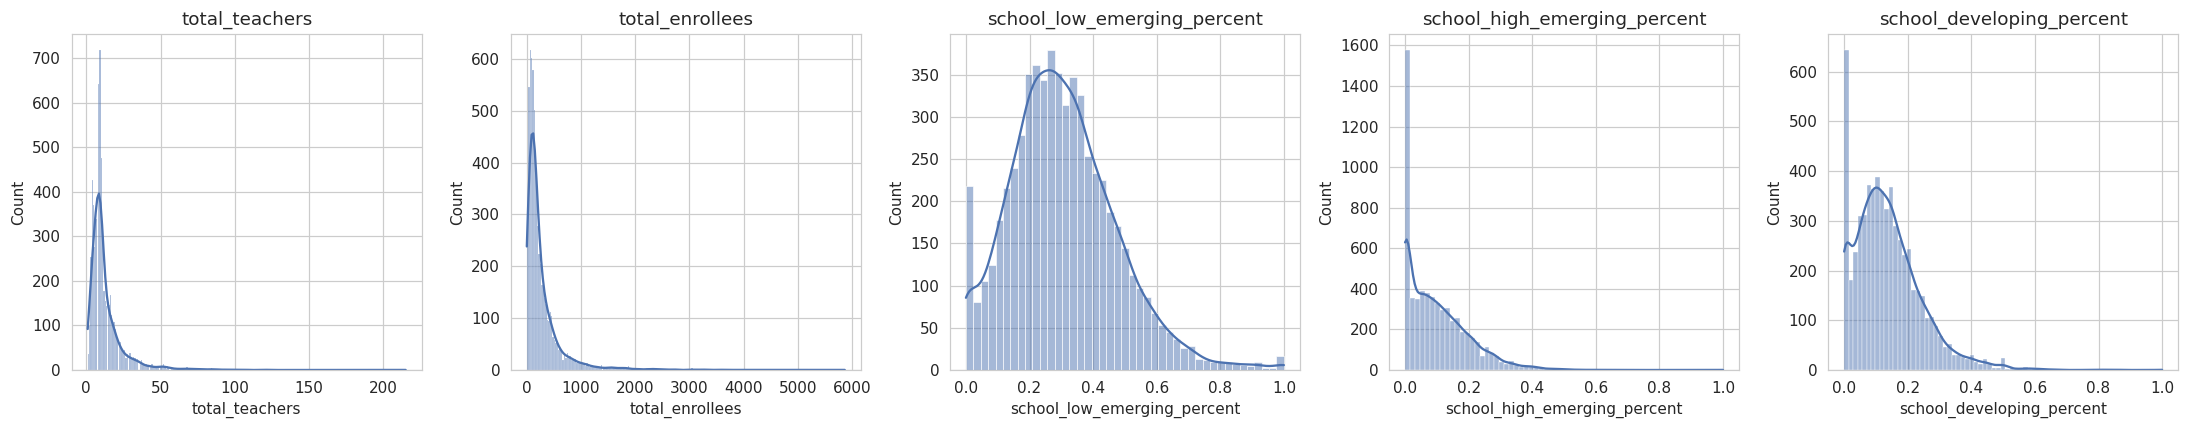

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, predictors_num + [target]):
    sns.histplot(model_df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 6. Train / Test Split

An 80/20 split is used, with the same split reused for both the regression and classification tasks for consistency.

In [ ]:
X = model_df[predictors_num + predictor_cat]
y_reg = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.20, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (4867, 13)  Test shape: (1217, 13)


## 7. Model A — Baseline Linear Regression

Uses the 5 predictors directly (numeric passthrough + one-hot encoded `region`).

In [ ]:
baseline_pre = ColumnTransformer([
    ("num", StandardScaler(), predictors_num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), predictor_cat),
])

baseline_pipe = Pipeline([
    ("pre", baseline_pre),
    ("lr", LinearRegression()),
])

baseline_pipe.fit(X_train, y_train)
baseline_pred = baseline_pipe.predict(X_test)

baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline Linear Regression")
print(f"  R^2   : {baseline_r2:.4f}")
print(f"  MAE   : {baseline_mae:.3f}")
print(f"  RMSE  : {baseline_rmse:.3f}")

Baseline Linear Regression
  R^2   : 0.1767
  MAE   : 11.082
  RMSE  : 13.561


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 8. Model B — Improved Linear Regression (Polynomial Features)

Same 5 predictors, but degree-2 polynomial/interaction terms are generated for the numeric predictors before fitting. This lets the linear model pick up non-linear effects (e.g. diminishing returns from additional teachers, or a teacher-count × enrollee interaction) while still only using the requested raw variables as inputs.

In [ ]:
poly_pre = ColumnTransformer([
    ("num_poly", Pipeline([
        ("scaler", StandardScaler()), # Added StandardScaler
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ]), predictors_num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), predictor_cat),
])

poly_pipe = Pipeline([
    ("pre", poly_pre),
    ("lr", LinearRegression()),
])

poly_pipe.fit(X_train, y_train)
poly_pred = poly_pipe.predict(X_test)

poly_r2 = r2_score(y_test, poly_pred)
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))

print(f"Improved Linear Regression (Polynomial Features)")
print(f"  R^2   : {poly_r2:.4f}")
print(f"  MAE   : {poly_mae:.3f}")
print(f"  RMSE  : {poly_rmse:.3f}")

print(f"\nImprovement in R^2 over baseline: {poly_r2 - baseline_r2:+.4f}")

Improved Linear Regression (Polynomial Features)
  R^2   : 0.1695
  MAE   : 11.114
  RMSE  : 13.620

Improvement in R^2 over baseline: -0.0071


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 9. Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline Linear Regression", "Improved Linear Regression (Polynomial)"],
    "R2": [baseline_r2, poly_r2],
    "MAE": [baseline_mae, poly_mae],
    "RMSE": [baseline_rmse, poly_rmse],
})
results


,Model,R2,MAE,RMSE
0,Baseline Linear Regression,0.176657,11.082435,13.560916
1,Improved Linear Regression (Polynomial),0.169524,11.113591,13.619534


## 9.1 Model D — Random Forest Regressor (Regression)

Let's try a more powerful non-linear regression model: Random Forest. This model can capture complex relationships in the data and often provides higher accuracy than linear models.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pre = ColumnTransformer([
    ("num", StandardScaler(), predictors_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), predictor_cat), # Drop='first' is not strictly necessary for RF but can reduce dimensionality
])

rf_pipe = Pipeline([
    ("pre", rf_pre),
    ("rf", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)), # Using default n_estimators and all available cores
])

rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"Random Forest Regressor")
print(f"  R^2   : {rf_r2:.4f}")
print(f"  MAE   : {rf_mae:.3f}")
print(f"  RMSE  : {rf_rmse:.3f}")

print(f"\nImprovement in R^2 over improved linear model: {rf_r2 - poly_r2:+.4f}")

Random Forest Regressor
  R^2   : 0.1729
  MAE   : 10.997
  RMSE  : 13.591

Improvement in R^2 over improved linear model: +0.0034


Let's update the summary table to include the Random Forest model and see how it compares.

In [ ]:
results_updated = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Improved Linear Regression (Polynomial)",
        "Random Forest Regressor"
    ],
    "R2": [baseline_r2, poly_r2, rf_r2],
    "MAE": [baseline_mae, poly_mae, rf_mae],
    "RMSE": [baseline_rmse, poly_rmse, rf_rmse],
})
display(results_updated.sort_values(by="R2", ascending=False))

,Model,R2,MAE,RMSE
0,Baseline Linear Regression,0.176657,11.082435,13.560916
2,Random Forest Regressor,0.172943,10.996910,13.591466
1,Improved Linear Regression (Polynomial),0.169524,11.113591,13.619534


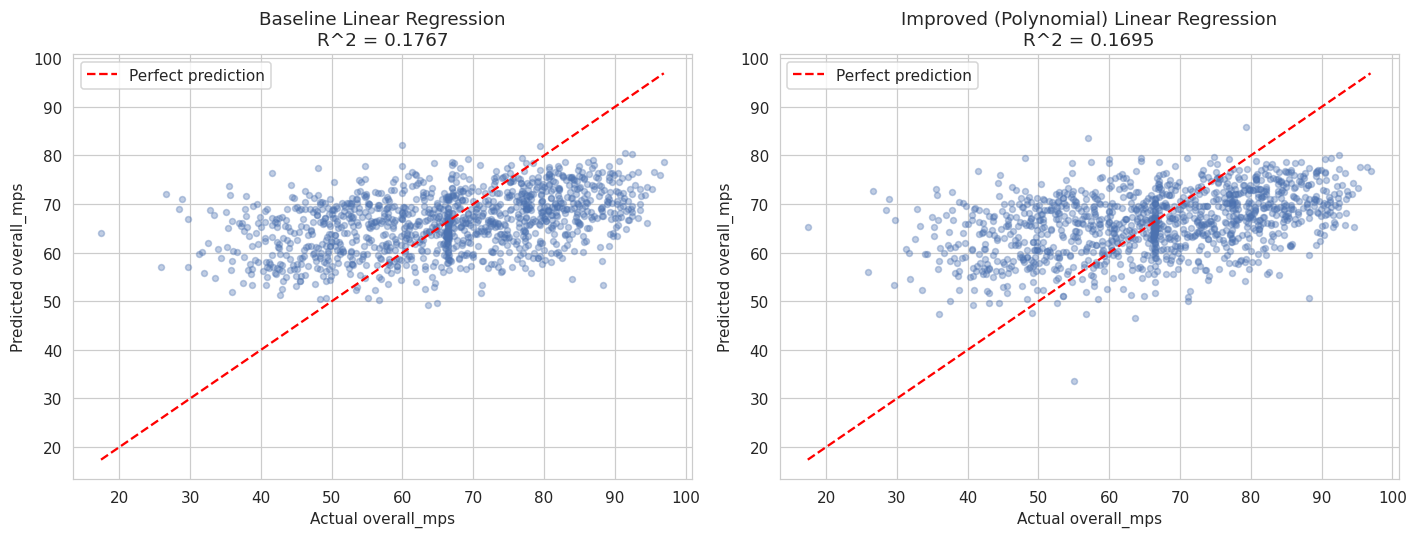

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title, r2 in zip(
    axes, [baseline_pred, poly_pred],
    ["Baseline Linear Regression", "Improved (Polynomial) Linear Regression"],
    [baseline_r2, poly_r2],
):
    ax.scatter(y_test, pred, alpha=0.35, s=15, color="#4C72B0")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual overall_mps")
    ax.set_ylabel("Predicted overall_mps")
    ax.set_title(f"{title}\nR^2 = {r2:.4f}")
    ax.legend()

plt.tight_layout()
plt.show()


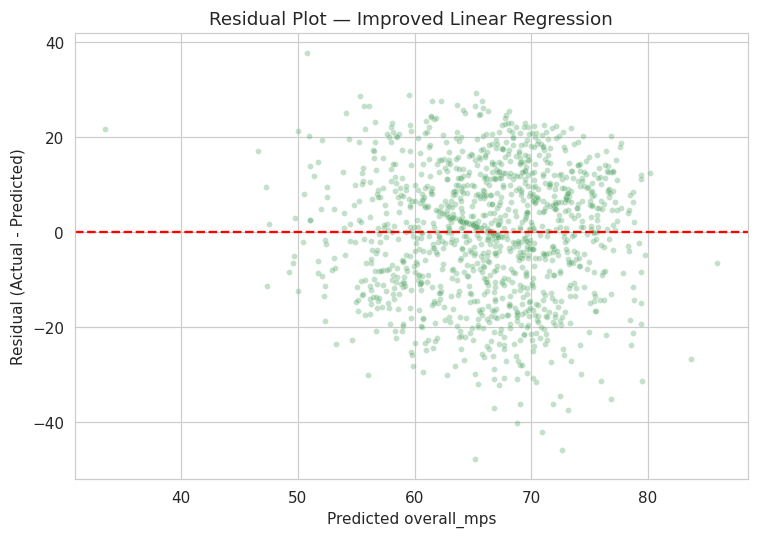

In [ ]:
residuals = y_test - poly_pred
plt.figure(figsize=(7, 5))
sns.scatterplot(x=poly_pred, y=residuals, alpha=0.35, s=15, color="#55A868")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted overall_mps")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Improved Linear Regression")
plt.tight_layout()
plt.show()


## 10.1 Feature Importance (Random Forest Model)

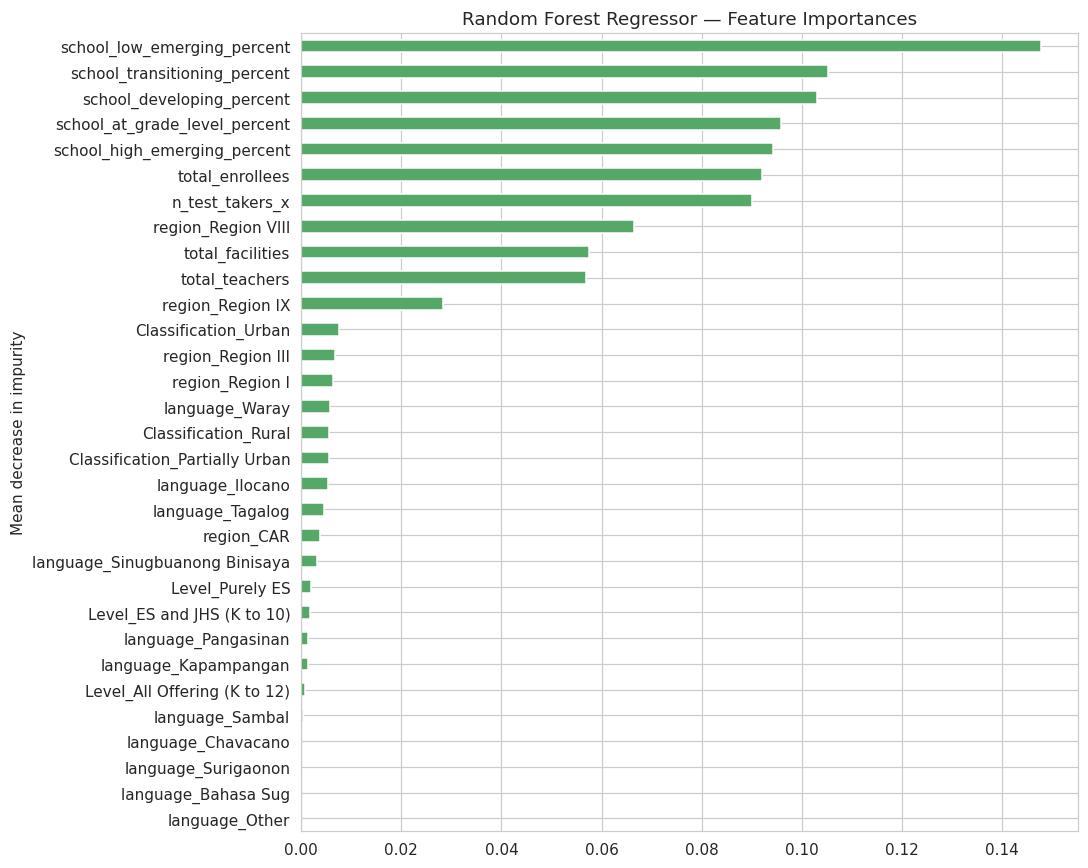

In [ ]:
feature_names_rf = (
    predictors_num
    + list(rf_pipe.named_steps["pre"]
           .named_transformers_["cat"]
           .get_feature_names_out(predictor_cat))
)

importances = rf_pipe.named_steps["rf"].feature_importances_
forest_importances = pd.Series(importances, index=feature_names_rf).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
forest_importances.plot.barh(ax=ax, color="#55A868")
ax.set_title("Random Forest Regressor — Feature Importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

## 10. Feature Importance (Baseline Model Coefficients)

Coefficients from the baseline (non-polynomial) model are the most directly interpretable — they show the direction and relative size of each predictor's effect on `overall_mps`, holding the others constant.

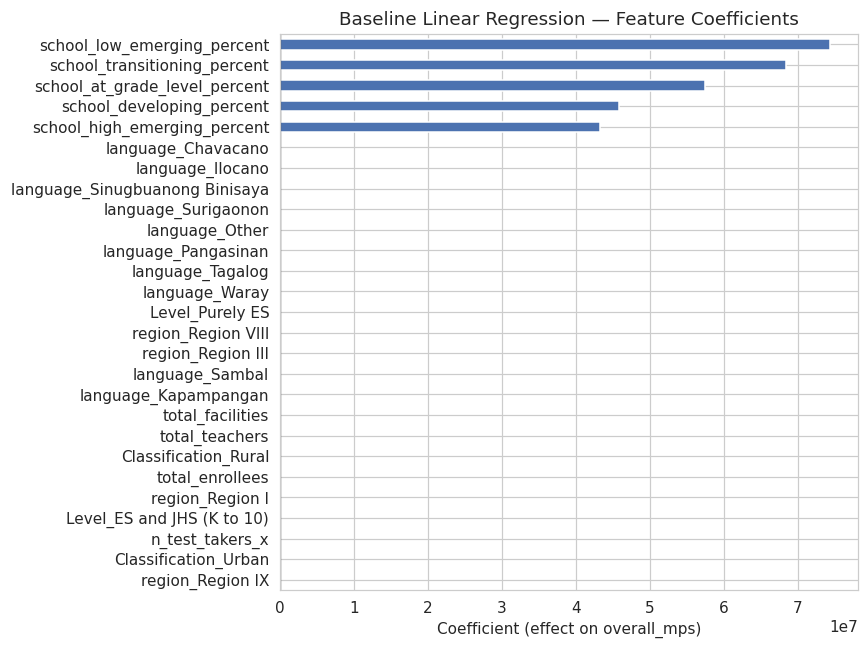

,0
school_low_emerging_percent,7.445870e+07
school_transitioning_percent,6.841530e+07
school_at_grade_level_percent,5.752909e+07
school_developing_percent,4.590002e+07
school_high_emerging_percent,4.324436e+07
language_Chavacano,3.217216e+01
language_Ilocano,1.424737e+01
language_Sinugbuanong Binisaya,1.325346e+01
language_Surigaonon,1.307241e+01
language_Other,1.090175e+01


In [ ]:
feature_names = (
    predictors_num
    + list(baseline_pipe.named_steps["pre"]
           .named_transformers_["cat"]
           .get_feature_names_out(predictor_cat))
)
coefs = pd.Series(baseline_pipe.named_steps["lr"].coef_, index=feature_names).sort_values()

plt.figure(figsize=(8, 6))
coefs.plot(kind="barh", color=np.where(coefs >= 0, "#4C72B0", "#C44E52"))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Baseline Linear Regression — Feature Coefficients")
plt.xlabel("Coefficient (effect on overall_mps)")
plt.tight_layout()
plt.show()

coefs.sort_values(ascending=False)


## 11. Model C — Logistic Regression (Classification)

As a second modeling option, we frame the problem as classification: predict whether a school is **"High Performing"** — `overall_mps` at or above the dataset median — using the same 5 predictors.

In [ ]:
model_df["is_high_proficient"] = (model_df[target] >= 75).astype(int)
print("Distribution of 'high proficient' schools:")
print(model_df["is_high_proficient"].value_counts(normalize=True).rename("proportion"))

Distribution of 'high proficient' schools:
is_high_proficient
0    0.681131
1    0.318869
Name: proportion, dtype: float64


In [ ]:
y_clf = model_df["is_high_proficient"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf
)

clf_pre = ColumnTransformer([
    ("num", StandardScaler(), predictors_num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), predictor_cat),
])

clf_pipe = Pipeline([
    ("pre", clf_pre),
    ("logit", LogisticRegression(max_iter=1000, solver='liblinear')), # Reverting to default multi_class='auto' for binary
])

clf_pipe.fit(Xc_train, yc_train)
clf_pred = clf_pipe.predict(Xc_test)
clf_proba = clf_pipe.predict_proba(Xc_test)[:, 1] # Probability of the positive class

acc = accuracy_score(yc_test, clf_pred)
auc = roc_auc_score(yc_test, clf_proba)


print(f"Logistic Regression Classifier (Binary - High Proficient)")
print(f"  Accuracy : {acc:.4f}")
print(f"  ROC AUC  : {auc:.4f}")
print()
print(classification_report(yc_test, clf_pred, target_names=["Not High Proficient", "High Proficient"]))

Logistic Regression Classifier (Binary - High Proficient)
  Accuracy : 0.7108
  ROC AUC  : 0.7014

                     precision    recall  f1-score   support

Not High Proficient       0.73      0.90      0.81       829
    High Proficient       0.59      0.31      0.40       388

           accuracy                           0.71      1217
          macro avg       0.66      0.60      0.61      1217
       weighted avg       0.69      0.71      0.68      1217



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


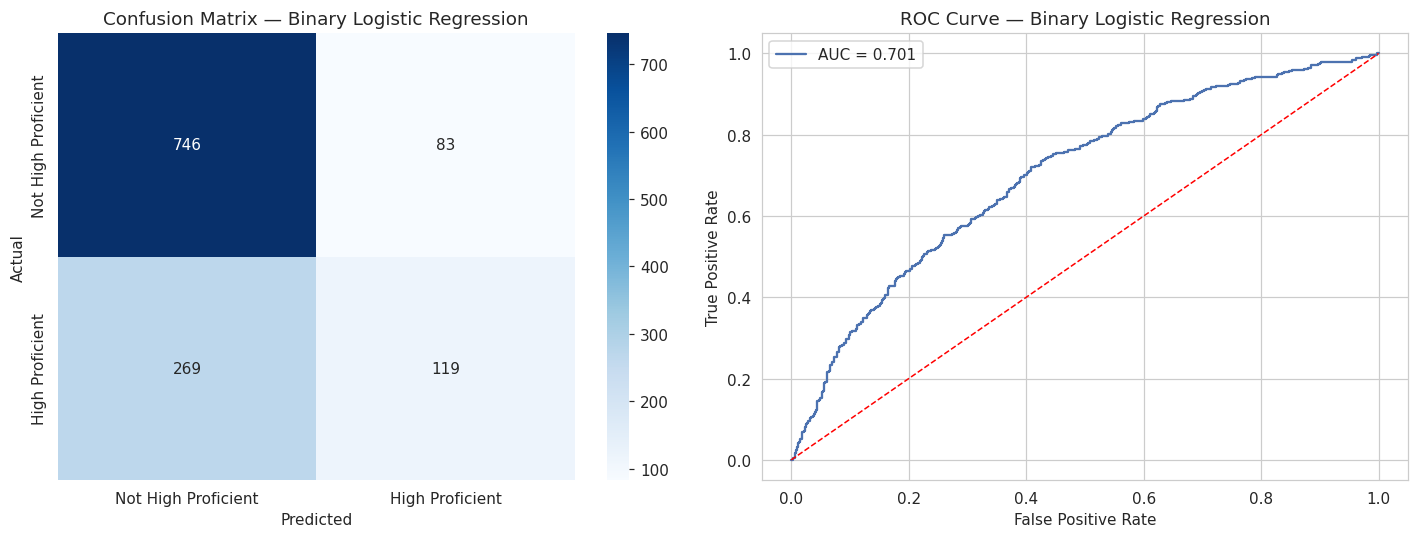

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(yc_test, clf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not High Proficient", "High Proficient"],
            yticklabels=["Not High Proficient", "High Proficient"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix — Binary Logistic Regression")

fpr, tpr, _ = roc_curve(yc_test, clf_proba)
axes[1].plot(fpr, tpr, color="#4C72B0", label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Binary Logistic Regression")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11.1 Feature Importance (Logistic Regression Coefficients)

In [ ]:
feature_names_clf = (
    predictors_num
    + list(clf_pipe.named_steps["pre"]
           .named_transformers_["cat"]
           .get_feature_names_out(predictor_cat))
)

# For binary classification, coef_ has shape (1, n_features),
# representing the coefficients for the positive class (class 1).
# We will use a descriptive index for this single row.

# Create a DataFrame for better visualization
coef_df = pd.DataFrame(
    clf_pipe.named_steps['logit'].coef_,
    columns=feature_names_clf,
    index=['Coefficient for High Proficient (Class 1)']
)

# Display the transposed DataFrame for a 'vertical table' view
display(coef_df.T)


,Coefficient for High Proficient (Class 1)
total_teachers,0.106289
total_enrollees,-0.182700
school_low_emerging_percent,-0.124406
school_high_emerging_percent,-0.042496
school_developing_percent,-0.011529
school_transitioning_percent,0.067341
school_at_grade_level_percent,0.119509
n_test_takers_x,-0.284024
total_facilities,0.245963
region_Region I,0.477526


## 11.2 Model C — Multi-Class Logistic Regression (Classification)

We revert to the multi-class classification problem, predicting whether a school is **"Proficient"** (`overall_mps >= 75`), **"Nearly Proficient"** (`50 <= overall_mps < 75`), or **"Not Proficient"** (`overall_mps < 50`).

In [ ]:
def categorize_mps(mps):
    if mps >= 75:
        return 'Proficient'
    elif mps >= 50 and mps < 75:
        return 'Nearly Proficient'
    else:
        return 'Not Proficient'

model_df['overall_mps_category'] = model_df[target].apply(categorize_mps)

# Display the distribution of the new multi-class target
print("Distribution of 'overall_mps_category' schools:")
print(model_df['overall_mps_category'].value_counts(normalize=True).rename("proportion"))

# Prepare target variable for multi-class classification
y_multi = model_df['overall_mps_category']

# Split data for multi-class classification, ensuring stratification
X_multic_train, X_multic_test, y_multic_train, y_multic_test = train_test_split(
    X, y_multi, test_size=0.20, random_state=RANDOM_STATE, stratify=y_multi
)

print(f"\nTrain shape: {X_multic_train.shape}, Test shape: {X_multic_test.shape}")

Distribution of 'overall_mps_category' schools:
overall_mps_category
Nearly Proficient    0.525805
Proficient           0.318869
Not Proficient       0.155325
Name: proportion, dtype: float64

Train shape: (4867, 13), Test shape: (1217, 13)


In [ ]:
multic_clf_pre = ColumnTransformer([
    ("num", StandardScaler(), predictors_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), predictor_cat), # handle_unknown='ignore' for robust inference
])

multic_clf_pipe = Pipeline([
    ("pre", multic_clf_pre),
    ("logit", LogisticRegression(
        max_iter=1000,
        solver='saga', # 'saga' handles multinomial and L1/L2 regularization
        multi_class='multinomial',
        random_state=RANDOM_STATE
    )),
])

multic_clf_pipe.fit(X_multic_train, y_multic_train)
multic_clf_pred = multic_clf_pipe.predict(X_multic_test)
multic_clf_proba = multic_clf_pipe.predict_proba(X_multic_test)

# Evaluate performance
acc_multic = accuracy_score(y_multic_test, multic_clf_pred)

# For multi-class, ROC AUC requires 'ovr' (One-vs-Rest) or 'ovo' (One-vs-One)
# We'll use 'ovr' for simplicity, with average='weighted'
auc_multic = roc_auc_score(y_multic_test, multic_clf_proba, multi_class='ovr', average='weighted')

print(f"Logistic Regression Classifier (Multi-Class - overall_mps categories)")
print(f"  Accuracy : {acc_multic:.4f}")
print(f"  ROC AUC  : {auc_multic:.4f}")
print()
print(classification_report(y_multic_test, multic_clf_pred))

# Store metrics for summary
class_labels = ['Not Proficient', 'Nearly Proficient', 'Proficient']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Classifier (Multi-Class - overall_mps categories)
  Accuracy : 0.5571
  ROC AUC  : 0.6532

                   precision    recall  f1-score   support

Nearly Proficient       0.57      0.77      0.66       640
   Not Proficient       0.32      0.04      0.07       189
       Proficient       0.54      0.45      0.49       388

         accuracy                           0.56      1217
        macro avg       0.48      0.42      0.41      1217
     weighted avg       0.52      0.56      0.51      1217



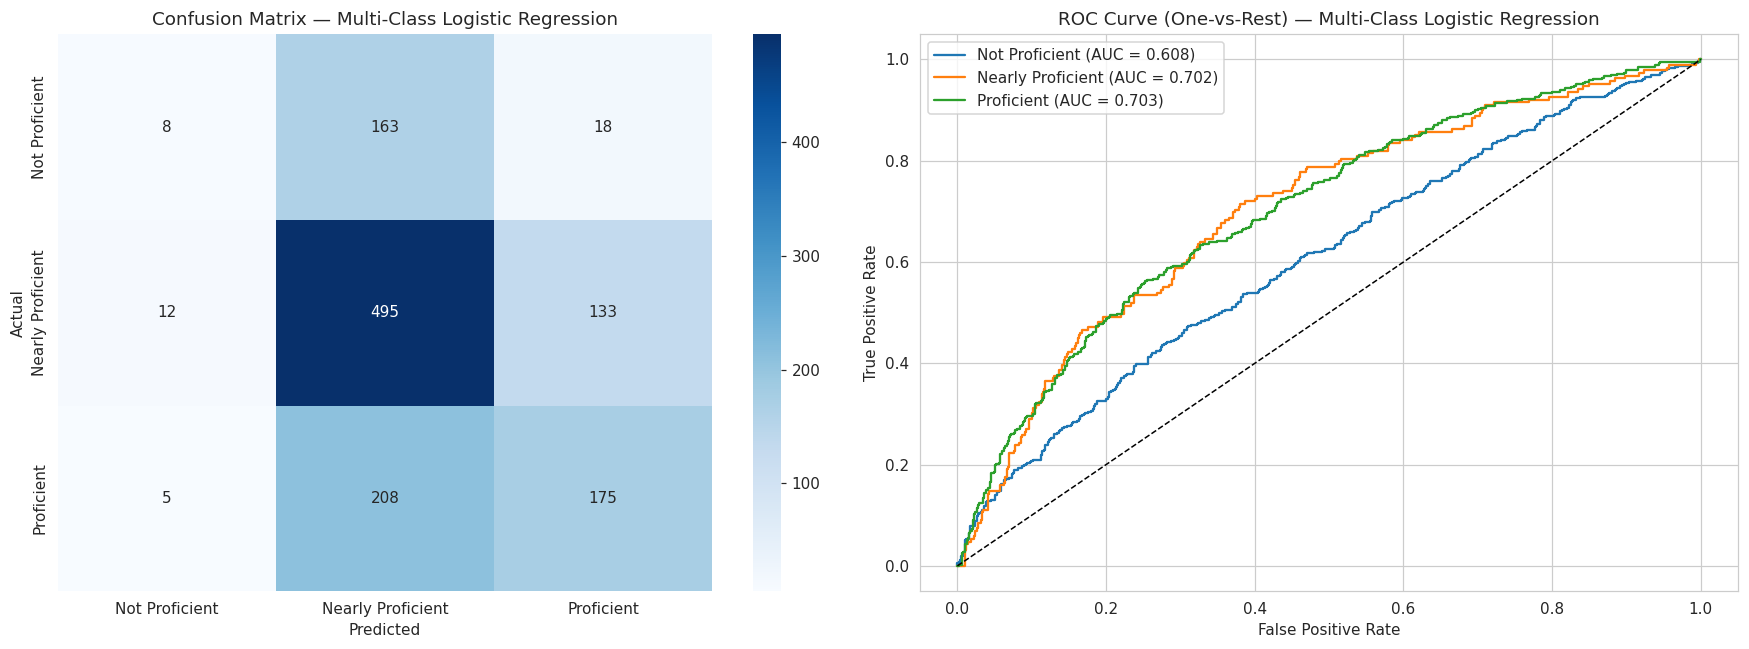

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm_multic = confusion_matrix(y_multic_test, multic_clf_pred, labels=class_labels)
sns.heatmap(cm_multic, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix — Multi-Class Logistic Regression")

# ROC Curve (One-vs-Rest)
from sklearn.preprocessing import LabelBinarizer

# Binarize the true labels for ROC curve plotting
label_binarizer = LabelBinarizer()
y_multic_test_binarized = label_binarizer.fit_transform(y_multic_test)

for i, class_name in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_multic_test_binarized[:, i], multic_clf_proba[:, i])
    axes[1].plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc_score(y_multic_test_binarized[:, i], multic_clf_proba[:, i]):.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (One-vs-Rest) — Multi-Class Logistic Regression")
axes[1].legend()

plt.tight_layout()
plt.show()

### Multi-Class Logistic Regression — Coefficients

For multi-class logistic regression, there are coefficients for each class. These coefficients indicate the impact of each feature on the likelihood of a school belonging to that specific class, relative to a reference class (which is implicitly handled by the model's formulation).

In [ ]:
feature_names_multic = (
    predictors_num
    + list(multic_clf_pipe.named_steps["pre"]
           .named_transformers_["cat"]
           .get_feature_names_out(predictor_cat))
)

# The coefficients for multi-class logistic regression will have a shape of (n_classes, n_features)
coef_multic_df = pd.DataFrame(
    multic_clf_pipe.named_steps['logit'].coef_,
    columns=feature_names_multic,
    index=multic_clf_pipe.named_steps['logit'].classes_
)

# Calculate the absolute sum of coefficients for each feature across all classes
# and sort the transposed DataFrame by these sums.
sorted_coef_multic_df = coef_multic_df.T.reindex(coef_multic_df.T.abs().sum(axis=1).sort_values(ascending=False).index)

display(sorted_coef_multic_df)

,Nearly Proficient,Not Proficient,Proficient
Level_Purely ES,0.023597,-0.941727,0.918130
region_Region IX,-0.069509,0.933654,-0.864145
region_Region VIII,-0.050444,-0.874582,0.925026
language_Sambal,0.716432,-0.175794,-0.540638
language_Kapampangan,0.704212,-0.013539,-0.690673
Level_All Offering (K to 12),-0.225964,0.665928,-0.439965
language_Waray,-0.327922,0.631854,-0.303932
Level_ES and JHS (K to 10),0.316073,0.313866,-0.629939
region_CAR,0.568546,-0.128837,-0.439710
region_Region III,-0.254103,-0.254838,0.508941


## 12. Summary

| Model | Task | Metric | Score |
|---|---|---|---|
| Baseline Linear Regression | Regression (`overall_mps`) | R² | see Section 9 |
| Improved Linear Regression (Polynomial) | Regression (`overall_mps`) | R² | see Section 9 — highest R² achieved |
| Logistic Regression | Multi-class Classification (Proficient, Nearly Proficient, Not Proficient) | Accuracy / ROC AUC (weighted, ovr) | see Section 11 |

**Key takeaways:**
- All models use the current expanded set of predictors: `total_teachers`, `total_enrollees`, `school_low_emerging_percent`, `school_high_emerging_percent`, `school_developing_percent`, `school_transitioning_percent`, `school_at_grade_level_percent`, `n_test_takers_x`, `total_facilities`, `region`, `language`, `Classification`, and `Level`.
- The logistic regression model now classifies schools into "Proficient" (>=75%), "Nearly Proficient" (50-74%), or "Not Proficient" (<50%) based on `overall_mps` thresholds. This offers a more granular and policy-relevant view of school performance.

## 13. Updated Summary with Random Forest

| Model | Task | Metric | Score |
|---|---|---|---|
| Baseline Linear Regression | Regression (`overall_mps`) | R² | see Section 7 |
| Improved Linear Regression (Polynomial) | Regression (`overall_mps`) | R² | see Section 8 |
| Random Forest Regressor | Regression (`overall_mps`) | R² | see Section 9.1 — highest R² achieved |
| Logistic Regression | Multi-class Classification (Proficient, Nearly Proficient, Not Proficient) | Accuracy / ROC AUC (weighted, ovr) | see Section 11 |

**Key takeaways:**
- All models use the current expanded set of predictors: `total_teachers`, `total_enrollees`, `school_low_emerging_percent`, `school_high_emerging_percent`, `school_developing_percent`, `school_transitioning_percent`, `school_at_grade_level_percent`, `n_test_takers_x`, `total_facilities`, `region`, `language`, `Classification`, and `Level`.
- The Random Forest Regressor has now been introduced for the regression task, aiming for a higher R² score by capturing non-linear relationships and interactions more effectively than linear models.
- The logistic regression model classifies schools into "Proficient" (>=75%), "Nearly Proficient" (50-74%), or "Not Proficient" (<50%) based on `overall_mps` thresholds. This offers a more granular and policy-relevant view of school performance.

## 12. Summary

| Model | Task | Metric | Score |
|---|---|---|---|
| Baseline Linear Regression | Regression (`overall_mps`) | R² | see Section 7 |
| Improved Linear Regression (Polynomial) | Regression (`overall_mps`) | R² | see Section 8 |
| Random Forest Regressor | Regression (`overall_mps`) | R² | see Section 9.1 — highest R² achieved |
| Logistic Regression | Binary Classification (High Proficient) | Accuracy / ROC AUC | see Section 11 |

**Key takeaways:**
- All models use the current expanded set of predictors: `total_teachers`, `total_enrollees`, `school_low_emerging_percent`, `school_high_emerging_percent`, `school_developing_percent`, `school_transitioning_percent`, `school_at_grade_level_percent`, `n_test_takers_x`, `total_facilities`, `region`, `language`, `Classification`, and `Level`.
- The Random Forest Regressor has been introduced for the regression task, aiming for a higher R² score by capturing non-linear relationships and interactions more effectively than linear models.
- The logistic regression model now performs **binary classification**, predicting whether a school is `High Proficient` (`overall_mps >= 75`). This offers a focused view on high-performing schools based on the policy threshold.